In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# (1) Data Load

In [30]:

df = pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Desktop\big_mart_sales.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


# (2) Shape Check

In [31]:
print(df.shape)

(8523, 12)


# (3) Dataset Information

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# (4) Statistical Summary

In [33]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


# (5) Missing Values Check

In [34]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

# before 

# (6) Missing Value Treatment

In [35]:
df['Item_Weight'].fillna(
df['Item_Weight'].mean(),
inplace=True)

df['Outlet_Size'].fillna(
df['Outlet_Size'].mode()[0],
inplace=True)

C:\Users\Aamir choudhary\AppData\Local\Temp\ipykernel_6028\2814069489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(
C:\Users\Aamir choudhary\AppData\Local\Temp\ipykernel_6028\2814069489.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

# after

In [36]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

# (7) Duplicate Check

In [37]:
df.duplicated().sum()

np.int64(0)

# drop_dublicate_value

In [38]:
df.drop_duplicates(inplace=True)

# (8) Unique Values

In [39]:
for i in df.columns:

    print(i,df[i].nunique())

Item_Identifier 1559
Item_Weight 416
Item_Fat_Content 5
Item_Visibility 7880
Item_Type 16
Item_MRP 5938
Outlet_Identifier 10
Outlet_Establishment_Year 9
Outlet_Size 3
Outlet_Location_Type 3
Outlet_Type 4
Item_Outlet_Sales 3493


# (9) Univariate Analysis

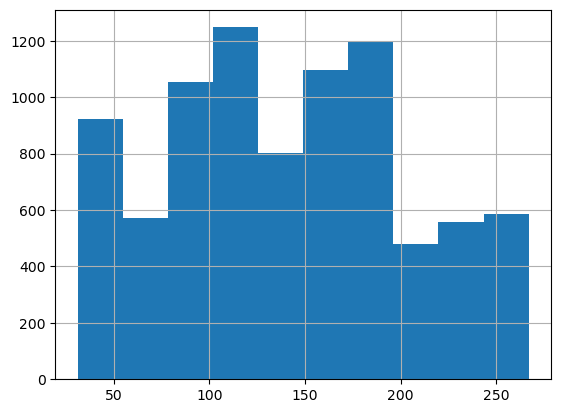

In [40]:
df["Item_MRP"].hist()

plt.show()

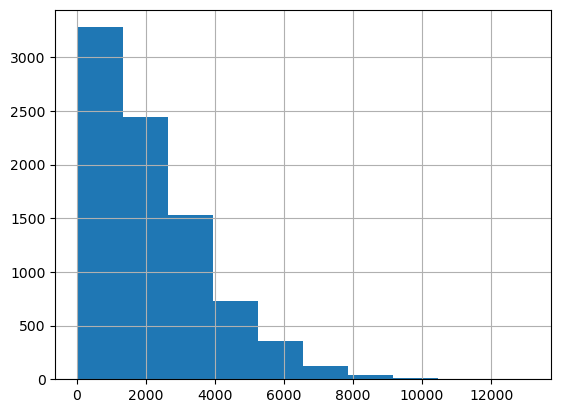

In [41]:
df["Item_Outlet_Sales"].hist()

plt.show()

# (10) Categorical Analysis

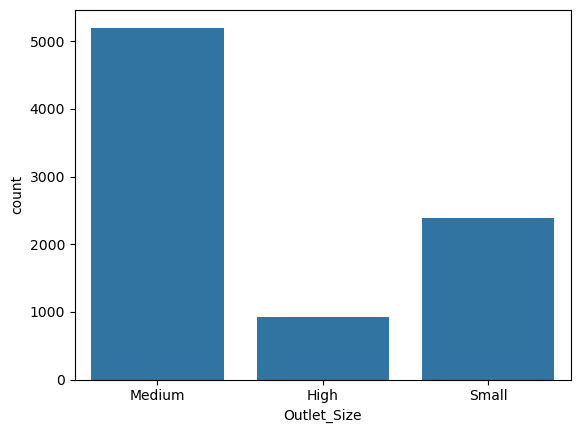

In [42]:
sns.countplot(
x='Outlet_Size',
data=df)

plt.show()

# (11) Bivariate Analysis

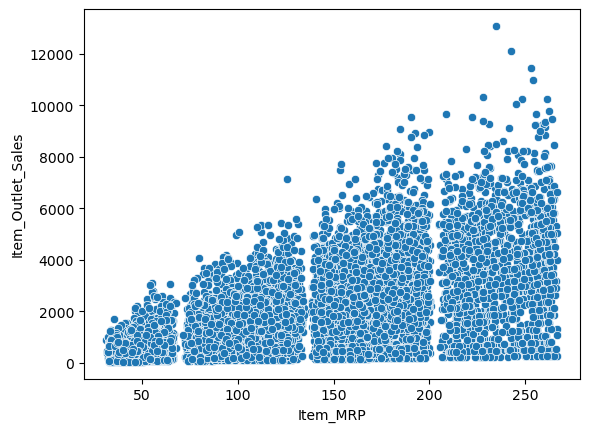

In [43]:
sns.scatterplot(
x='Item_MRP',
y='Item_Outlet_Sales',
data=df)

plt.show()

# (12) Correlation Heatmap

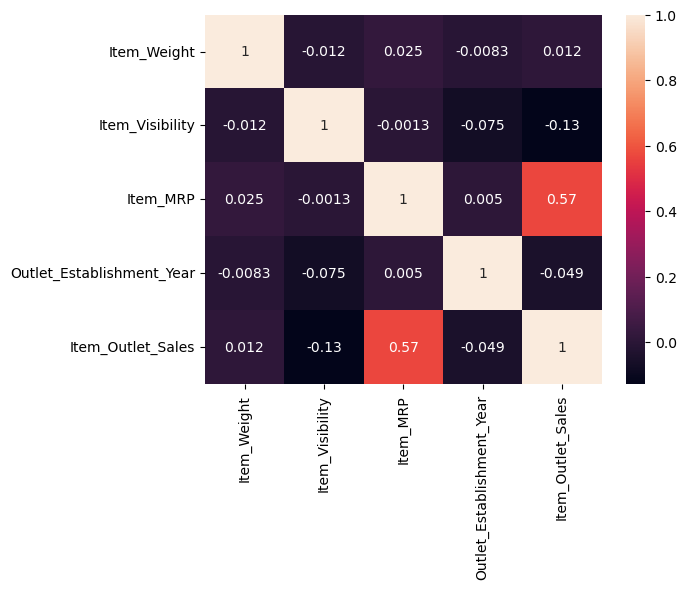

In [44]:
sns.heatmap(
df.select_dtypes(
include='number').corr(),

annot=True)

plt.show()

# (13) Feature Engineering

In [45]:
df['Outlet_Age']=2026-df[
'Outlet_Establishment_Year']

# (14) Label Encoding

In [46]:
le=LabelEncoder()

for i in df.select_dtypes(
include='object'):

    df[i]=le.fit_transform(
    df[i].astype(str))

# (15) Feature Selection

In [47]:
X=df.drop(
'Item_Outlet_Sales',
axis=1)

y=df[
'Item_Outlet_Sales']

# (16) Train Test Split

In [48]:
X_train,X_test,y_train,y_test= train_test_split(

X,
y,
test_size=0.2,
random_state=42
)

# (17) Linear Regression Model

In [49]:
model=LinearRegression()

model.fit(
X_train,
y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# (18) Prediction

In [50]:
pred=model.predict(
X_test)

# (19) Model Evaluation

In [57]:
print("MAE:",
mean_absolute_error(
y_test,pred))

print("MSE:",
mean_squared_error(
y_test,pred))

print("R2 Score:",
r2_score(
y_test,pred))

MAE: 855.2499115405119
MSE: 1291511.9190647881
R2 Score: 0.5248248187396568


# (20) Random Forest (Better Model)

In [58]:
rf=RandomForestRegressor()

rf.fit(
X_train,
y_train)

pred2=rf.predict(
X_test)

print(
r2_score(
y_test,
pred2))

0.5611388977959536
